# BUSINESS DATA ANALYTICS APPLIED LAB 2: RISK MANAGEMENT & OSH ANALYTICS
Un conglomerado de 150 empresas está alarmado por el aumento en los reportes de accidentes laborales. El costo de las incapacidades y el impacto humano están afectando la productividad global. La gerencia no solo necesita saber cuántos accidentes ocurren, sino que requiere identificar patrones de riesgo para implementar una estrategia de prevención. Su misión como analista de datos consiste en aplicar la metodología CRISP-DM para consolidar fuentes de datos dispersas, generar evidencia visual sobre los factores de riesgo (jornada, capacitación y sector) y proponer reglas de negocio preventivas.

**Integrantes:** Juan Garavito, Juan Fonseca y Cristian Villamil

_Actualizado: 16/02/2026_
_ebuitragob@ucentral.edu.co_

## Carga y transformación datos

In [1]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Paso 1: Carga y Preparación de Datos (Data Understanding)
df_trabajadores = pd.read_csv('data/trabajadores.csv')
df_empresas = pd.read_csv('data/empresas.csv')
df_accidentes = pd.read_csv('data/accidentes.csv')


In [3]:
# Paso 2: Consolidación de Información (Data Preparation / Triple Join)
# Unimos trabajadores con empresas
df_merge = pd.merge(df_trabajadores, df_empresas, left_on='empresa', right_on='id_empresa')

# Unir con accidentes (Left join para no perder a quienes NO tuvieron accidentes)
df_final = pd.merge(df_merge, df_accidentes, on='id_trabajador', how='left')

# Crear variable binaria: 1 si hubo accidente, 0 si no
df_final['incidente'] = df_final['id_accidente'].notnull().astype(int)

## Visualización

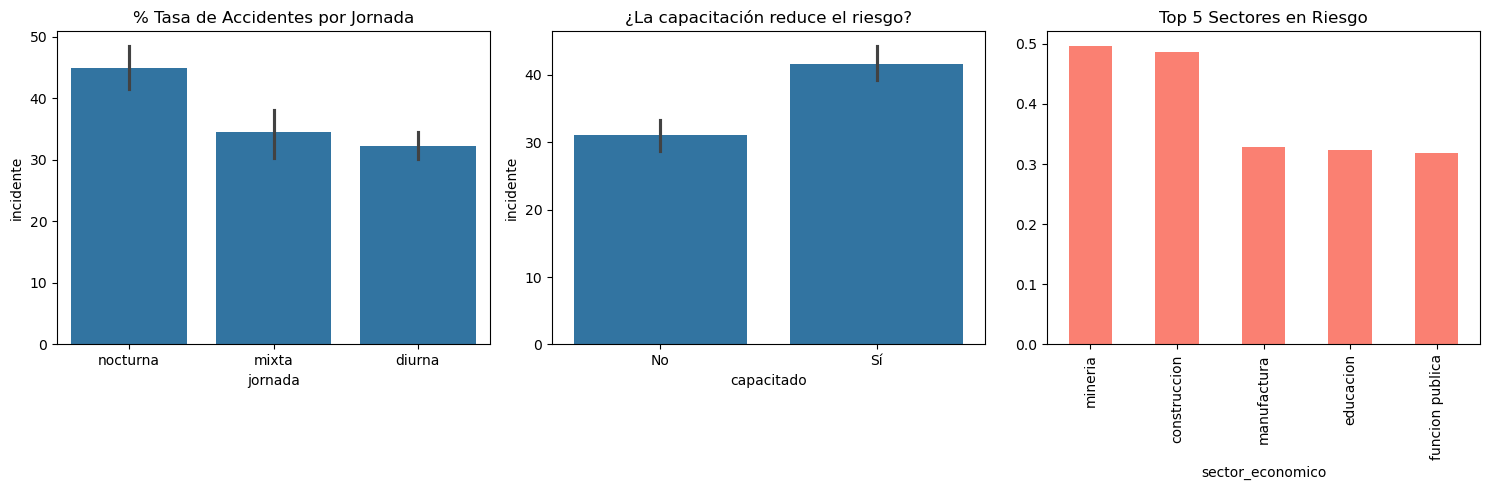

In [4]:
# Paso 3: Modelado Descriptivo (Visualización de Evidencia)
plt.figure(figsize=(15, 5))

# Gráfico 1: Riesgo por Jornada
plt.subplot(1, 3, 1)
sns.barplot(data=df_final, x='jornada', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.title('% Tasa de Accidentes por Jornada')

# Gráfico 2: Impacto de la Capacitación
plt.subplot(1, 3, 2)
sns.barplot(data=df_final, x='capacitado', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.xticks([0, 1], ['No', 'Sí'])
plt.title('¿La capacitación reduce el riesgo?')

# Gráfico 3: Sectores más críticos (Top 5)
plt.subplot(1, 3, 3)
df_final.groupby('sector_economico')['incidente'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='salmon')
plt.title('Top 5 Sectores en Riesgo')

plt.tight_layout()
plt.show()

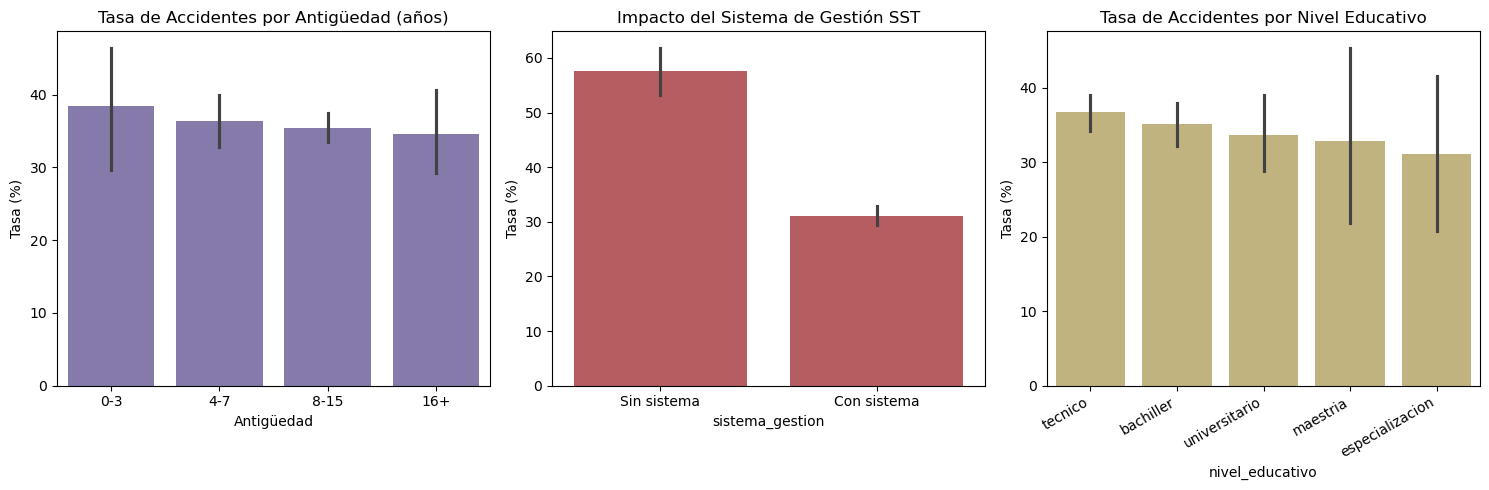

In [5]:
# --- SECCIÓN DE EXPLORACIÓN AUTÓNOMA ---
# Profundizamos con 3 variables adicionales: antigüedad, sistema de gestión y nivel educativo

plt.figure(figsize=(15, 5))

# Gráfico 4: Antigüedad (agrupada en rangos)
plt.subplot(1, 3, 1)
df_final['antiguedad_bin'] = pd.cut(df_final['antiguedad'], bins=[0, 3, 7, 15, 100],
                                     labels=['0-3', '4-7', '8-15', '16+'])
sns.barplot(data=df_final, x='antiguedad_bin', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100, order=['0-3','4-7','8-15','16+'], color='#8172B2')
plt.title('Tasa de Accidentes por Antigüedad (años)')
plt.ylabel('Tasa (%)')
plt.xlabel('Antigüedad')

# Gráfico 5: Sistema de gestión SST
plt.subplot(1, 3, 2)
sns.barplot(data=df_final, x='sistema_gestion', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100, color='#C44E52')
plt.xticks([0, 1], ['Sin sistema', 'Con sistema'])
plt.title('Impacto del Sistema de Gestión SST')
plt.ylabel('Tasa (%)')

# Gráfico 6: Nivel educativo
plt.subplot(1, 3, 3)
orden_edu = df_final.groupby('nivel_educativo')['incidente'].mean().sort_values(ascending=False).index
sns.barplot(data=df_final, x='nivel_educativo', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100, order=orden_edu, color='#CCB974')
plt.title('Tasa de Accidentes por Nivel Educativo')
plt.ylabel('Tasa (%)')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

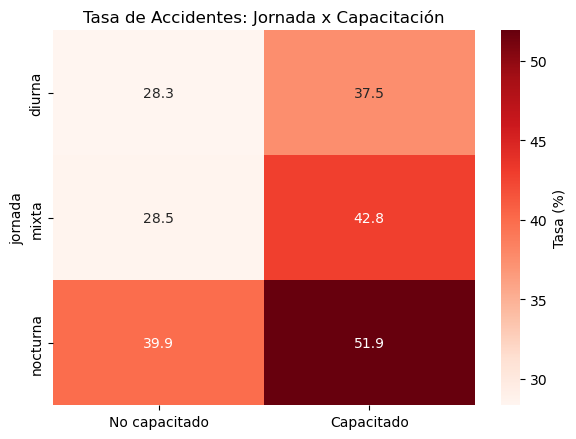

In [6]:
# Gráfico 7: Cruce Jornada x Capacitación (heatmap)
pivot = df_final.groupby(['jornada', 'capacitado'])['incidente'].mean().unstack() * 100
pivot.columns = ['No capacitado', 'Capacitado']
plt.figure(figsize=(6, 4.5))
sns.heatmap(pivot.loc[['diurna', 'mixta', 'nocturna']], annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'Tasa (%)'})
plt.title('Tasa de Accidentes: Jornada x Capacitación')
plt.tight_layout()
plt.show()

In [7]:
# Tabla resumen de tasas de accidentalidad por variable clave
print('Tasa global de accidentalidad: %.2f%%' % (df_final['incidente'].mean()*100))
print()
print('--- Por jornada ---')
print(df_final.groupby('jornada')['incidente'].mean().mul(100).round(2))
print()
print('--- Por capacitación ---')
print(df_final.groupby('capacitado')['incidente'].mean().mul(100).round(2))
print()
print('--- Por sistema de gestión ---')
print(df_final.groupby('sistema_gestion')['incidente'].mean().mul(100).round(2))
print()
print('--- Top 5 sectores ---')
print(df_final.groupby('sector_economico')['incidente'].mean().sort_values(ascending=False).head(5).mul(100).round(2))

Tasa global de accidentalidad: 35.57%

--- Por jornada ---
jornada
diurna      32.26
mixta       34.49
nocturna    44.96
Name: incidente, dtype: float64

--- Por capacitación ---
capacitado
0    31.03
1    41.67
Name: incidente, dtype: float64

--- Por sistema de gestión ---
sistema_gestion
0    57.62
1    31.10
Name: incidente, dtype: float64

--- Top 5 sectores ---
sector_economico
mineria            49.59
construccion       48.62
manufactura        32.84
educacion          32.32
funcion publica    31.87
Name: incidente, dtype: float64


## Análisis

**Diagnóstico de factores de riesgo**

- **Jornada:** la jornada **nocturna** es la más peligrosa, con una tasa de accidentalidad de **44.96%**, frente a 32.26% en jornada diurna y 34.49% en jornada mixta. Trabajar de noche incrementa el riesgo en cerca de 13 puntos porcentuales frente al día.
- **Capacitación:** contrario a lo esperado, los trabajadores marcados como *capacitados* muestran una tasa de accidentalidad **mayor** (41.67%) que los no capacitados (31.03%). Esto no significa que la capacitación cause accidentes; lo más probable es una relación de **causalidad inversa**: las empresas capacitan preferentemente a los cargos y sectores de mayor exposición al riesgo (minería, construcción, jornada nocturna), por lo que el grupo "capacitado" concentra perfiles ya más riesgosos. Se recomienda un análisis controlado (regresión) antes de concluir que la capacitación es inefectiva.
- **Sector económico:** los sectores más críticos son **minería (49.59%)** y **construcción (48.62%)**, muy por encima de manufactura, educación y función pública (~32%).

**Hallazgos adicionales (exploración autónoma)**

- **Sistema de gestión SST:** es el factor con mayor poder discriminante encontrado: las empresas **sin** sistema de gestión tienen una tasa de accidentalidad de **57.62%**, frente a **31.10%** en las que sí lo tienen (una reducción de ~26 puntos porcentuales).
- **Antigüedad:** el riesgo es levemente mayor en los primeros años de vinculación (0-3 años: 38.4%) y decrece con la experiencia (16+ años: 34.6%), consistente con la curva de aprendizaje del trabajador nuevo.
- **Nivel educativo:** no muestra una diferencia relevante por sí solo (rango 31%-37%), lo que sugiere que no es un factor determinante frente a jornada, sector o sistema de gestión.
- **Cruce jornada x capacitación:** el patrón se mantiene en todas las jornadas: dentro de cada jornada, el grupo "capacitado" sigue teniendo tasas más altas, reforzando la hipótesis de que la capacitación se dirige a los puestos de mayor riesgo y no que la capacitación aumente el riesgo.

## Conclusiones

**Conclusiones y recomendación ERP**

1. El **sistema de gestión SST** es la palanca de mayor impacto disponible para la gerencia: activarlo en las empresas que aún no lo tienen podría reducir la accidentalidad casi a la mitad.
2. La **jornada nocturna**, especialmente en los sectores de **minería y construcción**, concentra el mayor riesgo y debe priorizarse en cualquier plan de intervención.
3. La capacitación, tal como está registrada hoy, no puede leerse como "inefectiva": su tasa más alta refleja que se aplica sobre la población ya expuesta a mayor riesgo. Se sugiere rediseñar el indicador (p. ej. capacitación reciente vs. antigua, o cruzar con severidad de la lesión) para medir su efecto real.

**Regla de negocio propuesta (Insight Accionable):**

> *SI* `jornada = 'nocturna'` *Y* `sector_economico ∈ {minería, construcción}` *Y* `sistema_gestion = 0` → el ERP debe generar automáticamente una **alerta de intervención prioritaria SST**: activación obligatoria de sistema de gestión, refuerzo de capacitación por turno nocturno y auditoría de campo en un plazo máximo de 30 días.